In [2]:
import numpy as np
import pandas as pd

emb = np.load("../data/gravityspy_processed/embeddings.npy")
meta = pd.read_csv("../data/gravityspy_processed/embeddings_metadata.csv")

emb.shape, meta.head()

# --- Patch: replace old/wrong labels with true glitch-class labels ---
truth = pd.read_csv("outputs/gravityspy_events_with_true_labels.csv")

print("meta rows:", len(meta), "truth rows:", len(truth))
print("meta columns:", list(meta.columns))

# Merge on gravityspy_id (must exist in meta)
meta2 = meta.merge(truth[["gravityspy_id", "true_label"]], on="gravityspy_id", how="left")

print("Matched true_label rate:", meta2["true_label"].notna().mean())
print("Unmatched rows:", meta2["true_label"].isna().sum())

# Decide what your downstream code expects the label column to be called.
# Common possibilities: 'label', 'class', 'glitch_class', etc.
# We'll create/override a standard 'label' column to be safe.
meta2["label"] = meta2["true_label"]

# Sanity: show counts
print("\nCorrect label counts:")
print(meta2["label"].value_counts())

# Replace meta in-memory so the rest of the notebook uses corrected labels
meta = meta2


meta rows: 34332 truth rows: 2118
meta columns: ['path', 'label_idx', 'label_name']


KeyError: 'gravityspy_id'

In [3]:
# --- Patch: replace old/wrong labels with true glitch-class labels ---
truth = pd.read_csv("outputs/gravityspy_events_with_true_labels.csv")

print("meta rows:", len(meta), "truth rows:", len(truth))
print("meta columns:", list(meta.columns))

# Merge on gravityspy_id (must exist in meta)
meta2 = meta.merge(truth[["gravityspy_id", "true_label"]], on="gravityspy_id", how="left")

print("Matched true_label rate:", meta2["true_label"].notna().mean())
print("Unmatched rows:", meta2["true_label"].isna().sum())

# Decide what your downstream code expects the label column to be called.
# Common possibilities: 'label', 'class', 'glitch_class', etc.
# We'll create/override a standard 'label' column to be safe.
meta2["label"] = meta2["true_label"]

# Sanity: show counts
print("\nCorrect label counts:")
print(meta2["label"].value_counts())

# Replace meta in-memory so the rest of the notebook uses corrected labels
meta = meta2


meta rows: 34332 truth rows: 2118
meta columns: ['path', 'label_idx', 'label_name']


KeyError: 'gravityspy_id'

In [4]:
import re

# Example path contains: ...\1080Lines\H1_09HE6k6EaS_spectrogram_0.5.png
# We want the 10-char token after "H1_" or "L1_".
meta["gravityspy_id"] = meta["path"].str.extract(r"[\\/](?:H1|L1)_([A-Za-z0-9]{10})_")[0]

print("gravityspy_id nulls:", meta["gravityspy_id"].isna().sum())
print("unique gravityspy_id:", meta["gravityspy_id"].nunique())

# show a few to confirm it looks right
meta[["path", "gravityspy_id", "label_name"]].head(3)


gravityspy_id nulls: 0
unique gravityspy_id: 8583


,path,gravityspy_id,label_name
0,C:\Users\mygam\Documents\gravityspy-project\da...,09HE6k6EaS,H1L1
1,C:\Users\mygam\Documents\gravityspy-project\da...,09HE6k6EaS,H1L1
2,C:\Users\mygam\Documents\gravityspy-project\da...,09HE6k6EaS,H1L1


In [5]:
truth = pd.read_csv("outputs/gravityspy_events_with_true_labels.csv")

meta2 = meta.merge(truth[["gravityspy_id", "true_label"]], on="gravityspy_id", how="left")

print("Match rate (true_label not null):", meta2["true_label"].notna().mean())
print("Matched rows:", meta2["true_label"].notna().sum(), "out of", len(meta2))

# Override the wrong label_name with corrected label (where available)
meta2["label_name_fixed"] = meta2["true_label"].fillna(meta2["label_name"])

print("\nFixed label counts (top 10):")
print(meta2["label_name_fixed"].value_counts().head(10))

# Replace meta so downstream uses the fixed labels
meta = meta2


Match rate (true_label not null): 0.24676686473261097
Matched rows: 8472 out of 34332

Fixed label counts (top 10):
label_name_fixed
H1L1              25860
Blip               6000
1080Lines          1312
1400Ripples         928
Air_Compressor      232
Name: count, dtype: int64


In [6]:
# --- Definitive fix: extract true label from path ---
# Assumes path contains .../H1L1/<GLITCH_CLASS>/filename.png

meta["true_label_from_path"] = meta["path"].str.extract(
    r"[\\/]H1L1[\\/](.*?)[\\/]"
)[0]

print("Null extracted labels:", meta["true_label_from_path"].isna().sum())
print("\nTrue label counts (top 10):")
print(meta["true_label_from_path"].value_counts().head(10))

# Override label_name everywhere
meta["label_name"] = meta["true_label_from_path"]


Null extracted labels: 0

True label counts (top 10):
true_label_from_path
Blip                   7476
Koi_Fish               3320
Low_Frequency_Burst    2628
Light_Modulation       2292
Violin_Mode            1888
Scattered_Light        1836
Extremely_Loud         1816
Power_Line             1812
Low_Frequency_Lines    1812
Scratchy               1416
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd

emb = np.load("../data/gravityspy_processed/embeddings.npy")
meta = pd.read_csv("../data/gravityspy_processed/embeddings_metadata.csv")

emb.shape, meta.head()

# --- Patch: replace old/wrong labels with true glitch-class labels ---
truth = pd.read_csv("outputs/gravityspy_events_with_true_labels.csv")

print("meta rows:", len(meta), "truth rows:", len(truth))
print("meta columns:", list(meta.columns))

# Merge on gravityspy_id (must exist in meta)
meta2 = meta.merge(truth[["gravityspy_id", "true_label"]], on="gravityspy_id", how="left")

print("Matched true_label rate:", meta2["true_label"].notna().mean())
print("Unmatched rows:", meta2["true_label"].isna().sum())

# Decide what your downstream code expects the label column to be called.
# Common possibilities: 'label', 'class', 'glitch_class', etc.
# We'll create/override a standard 'label' column to be safe.
meta2["label"] = meta2["true_label"]

# Sanity: show counts
print("\nCorrect label counts:")
print(meta2["label"].value_counts())

# Replace meta in-memory so the rest of the notebook uses corrected labels
meta = meta2

In [1]:
1 + 1


2

In [2]:
meta["label_name"].value_counts().head(20)


label_name
H1L1    34332
Name: count, dtype: int64

In [10]:
import umap

umap_2d = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

coords_2d = umap_2d.fit_transform(emb)
coords_2d.shape


C:\Users\mygam\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\mygam\AppData\Roaming\Python\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(34332, 2)

In [11]:
print("umap_x in columns?", "umap_x" in meta.columns)
print("umap_y in columns?", "umap_y" in meta.columns)
meta[["umap_x", "umap_y"]].head()


umap_x in columns? False
umap_y in columns? False


KeyError: "None of [Index(['umap_x', 'umap_y'], dtype='object')] are in the [columns]"

In [12]:
# Attach UMAP coords back onto meta
meta["umap_x"] = coords_2d[:, 0]
meta["umap_y"] = coords_2d[:, 1]

print("umap_x in columns?", "umap_x" in meta.columns)
print("umap_y in columns?", "umap_y" in meta.columns)
print(meta[["umap_x", "umap_y"]].head(3))


umap_x in columns? True
umap_y in columns? True
     umap_x    umap_y
0 -0.348981 -9.599299
1 -4.094698 -4.398118
2 -3.336335  1.403767


In [13]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    metric="euclidean",
    cluster_selection_method="eom",
)

cluster_labels = clusterer.fit_predict(meta[["umap_x", "umap_y"]].values)
meta["cluster_id"] = cluster_labels

meta["cluster_id"].value_counts().head(10)


cluster_id
 41    3915
 5     3697
 28    3498
 10    3479
 33    2106
-1     1970
 15    1662
 8      616
 20     603
 9      585
Name: count, dtype: int64

In [14]:
cluster_stats.sort_values("n", ascending=False).head(15)


NameError: name 'cluster_stats' is not defined

In [15]:
cluster_stats = (
    meta[meta["cluster_id"] != -1]  # exclude noise
      .groupby("cluster_id")
      .agg(
          n=("label_name", "size"),
          top_label=("label_name", lambda x: x.value_counts().idxmax()),
          top_label_count=("label_name", lambda x: x.value_counts().max()),
      )
)

cluster_stats["purity"] = cluster_stats["top_label_count"] / cluster_stats["n"]

cluster_stats.sort_values("n", ascending=False).head(15)


,n,top_label,top_label_count,purity
cluster_id,,,,
41,3915,Blip,1866,0.476628
5,3697,Blip,1867,0.505004
28,3498,Blip,1856,0.530589
10,3479,Blip,1867,0.536648
33,2106,Violin_Mode,471,0.223647
15,1662,Power_Line,424,0.255114
8,616,Low_Frequency_Burst,512,0.831169
20,603,Low_Frequency_Burst,507,0.840796
9,585,Repeating_Blips,544,0.929915


In [16]:
meta["umap_x"] = coords_2d[:, 0]
meta["umap_y"] = coords_2d[:, 1]

meta.to_csv("../data/gravityspy_processed/embeddings_umap.csv", index=False)
meta.head()


,path,label_idx,label_name,gravityspy_id,true_label,label_name_fixed,true_label_from_path,umap_x,umap_y,cluster_id
0,C:\Users\mygam\Documents\gravityspy-project\da...,0,1080Lines,09HE6k6EaS,1080Lines,1080Lines,1080Lines,-0.348981,-9.599299,33
1,C:\Users\mygam\Documents\gravityspy-project\da...,0,1080Lines,09HE6k6EaS,1080Lines,1080Lines,1080Lines,-4.094698,-4.398118,-1
2,C:\Users\mygam\Documents\gravityspy-project\da...,0,1080Lines,09HE6k6EaS,1080Lines,1080Lines,1080Lines,-3.336335,1.403767,37
3,C:\Users\mygam\Documents\gravityspy-project\da...,0,1080Lines,09HE6k6EaS,1080Lines,1080Lines,1080Lines,-3.679747,8.008952,11
4,C:\Users\mygam\Documents\gravityspy-project\da...,0,1080Lines,0Lojrrjlme,1080Lines,1080Lines,1080Lines,-0.265916,-9.569901,33


In [17]:
import pandas as pd

check = pd.read_csv("../data/gravityspy_processed/embeddings_umap.csv")

print("Rows:", len(check))
print("\nTop 10 labels:")
print(check["label_name"].value_counts().head(10))

print("\nTop 10 clusters:")
print(check["cluster_id"].value_counts().head(10))


Rows: 34332

Top 10 labels:
label_name
Blip                   7476
Koi_Fish               3320
Low_Frequency_Burst    2628
Light_Modulation       2292
Violin_Mode            1888
Scattered_Light        1836
Extremely_Loud         1816
Power_Line             1812
Low_Frequency_Lines    1812
Scratchy               1416
Name: count, dtype: int64

Top 10 clusters:
cluster_id
 41    3915
 5     3697
 28    3498
 10    3479
 33    2106
-1     1970
 15    1662
 8      616
 20     603
 9      585
Name: count, dtype: int64


In [18]:
# Rank clusters by ambiguity = (1 - purity) * size
ambiguous_clusters = (
    cluster_stats
    .assign(ambiguity=lambda d: (1 - d["purity"]) * d["n"])
    .sort_values("ambiguity", ascending=False)
)

ambiguous_clusters.head(10)


,n,top_label,top_label_count,purity,ambiguity
cluster_id,,,,,
41,3915,Blip,1866,0.476628,2049.0
5,3697,Blip,1867,0.505004,1830.0
28,3498,Blip,1856,0.530589,1642.0
33,2106,Violin_Mode,471,0.223647,1635.0
10,3479,Blip,1867,0.536648,1612.0
15,1662,Power_Line,424,0.255114,1238.0
25,385,Low_Frequency_Burst,104,0.270130,281.0
26,329,Whistle,78,0.237082,251.0
30,318,Whistle,78,0.245283,240.0


In [19]:
# Focus on cluster 33 only
cluster_33 = meta[meta["cluster_id"] == 33]

print("Total points in cluster 33:", len(cluster_33))
print("\nLabel composition:")
print(cluster_33["label_name"].value_counts())

print("\nLabel fractions:")
print((cluster_33["label_name"].value_counts(normalize=True)).round(3))


Total points in cluster 33: 2106

Label composition:
label_name
Violin_Mode            471
Power_Line             427
Low_Frequency_Lines    369
1080Lines              327
1400Ripples            232
Whistle                151
No_Glitch               42
Wandering_Line          40
None_of_the_Above       20
Air_Compressor          14
Scattered_Light          9
Low_Frequency_Burst      2
Extremely_Loud           2
Name: count, dtype: int64

Label fractions:
label_name
Violin_Mode            0.224
Power_Line             0.203
Low_Frequency_Lines    0.175
1080Lines              0.155
1400Ripples            0.110
Whistle                0.072
No_Glitch              0.020
Wandering_Line         0.019
None_of_the_Above      0.009
Air_Compressor         0.007
Scattered_Light        0.004
Low_Frequency_Burst    0.001
Extremely_Loud         0.001
Name: proportion, dtype: float64


In [22]:
from pathlib import Path

out_dir = Path("../findings/cluster_33_deep_dive")
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / "cluster33_contact_sheet_top6x5.png"

plt.tight_layout()
plt.savefig(out_path, dpi=200, bbox_inches="tight")
print("Saved:", out_path)
plt.show()


Saved: ..\findings\cluster_33_deep_dive\cluster33_contact_sheet_top6x5.png


<Figure size 640x480 with 0 Axes>

Top labels used: ['Violin_Mode', 'Power_Line', 'Low_Frequency_Lines', '1080Lines', '1400Ripples', 'Whistle']
Saved: ..\findings\cluster_33_deep_dive\cluster33_contact_sheet_top6x5.png


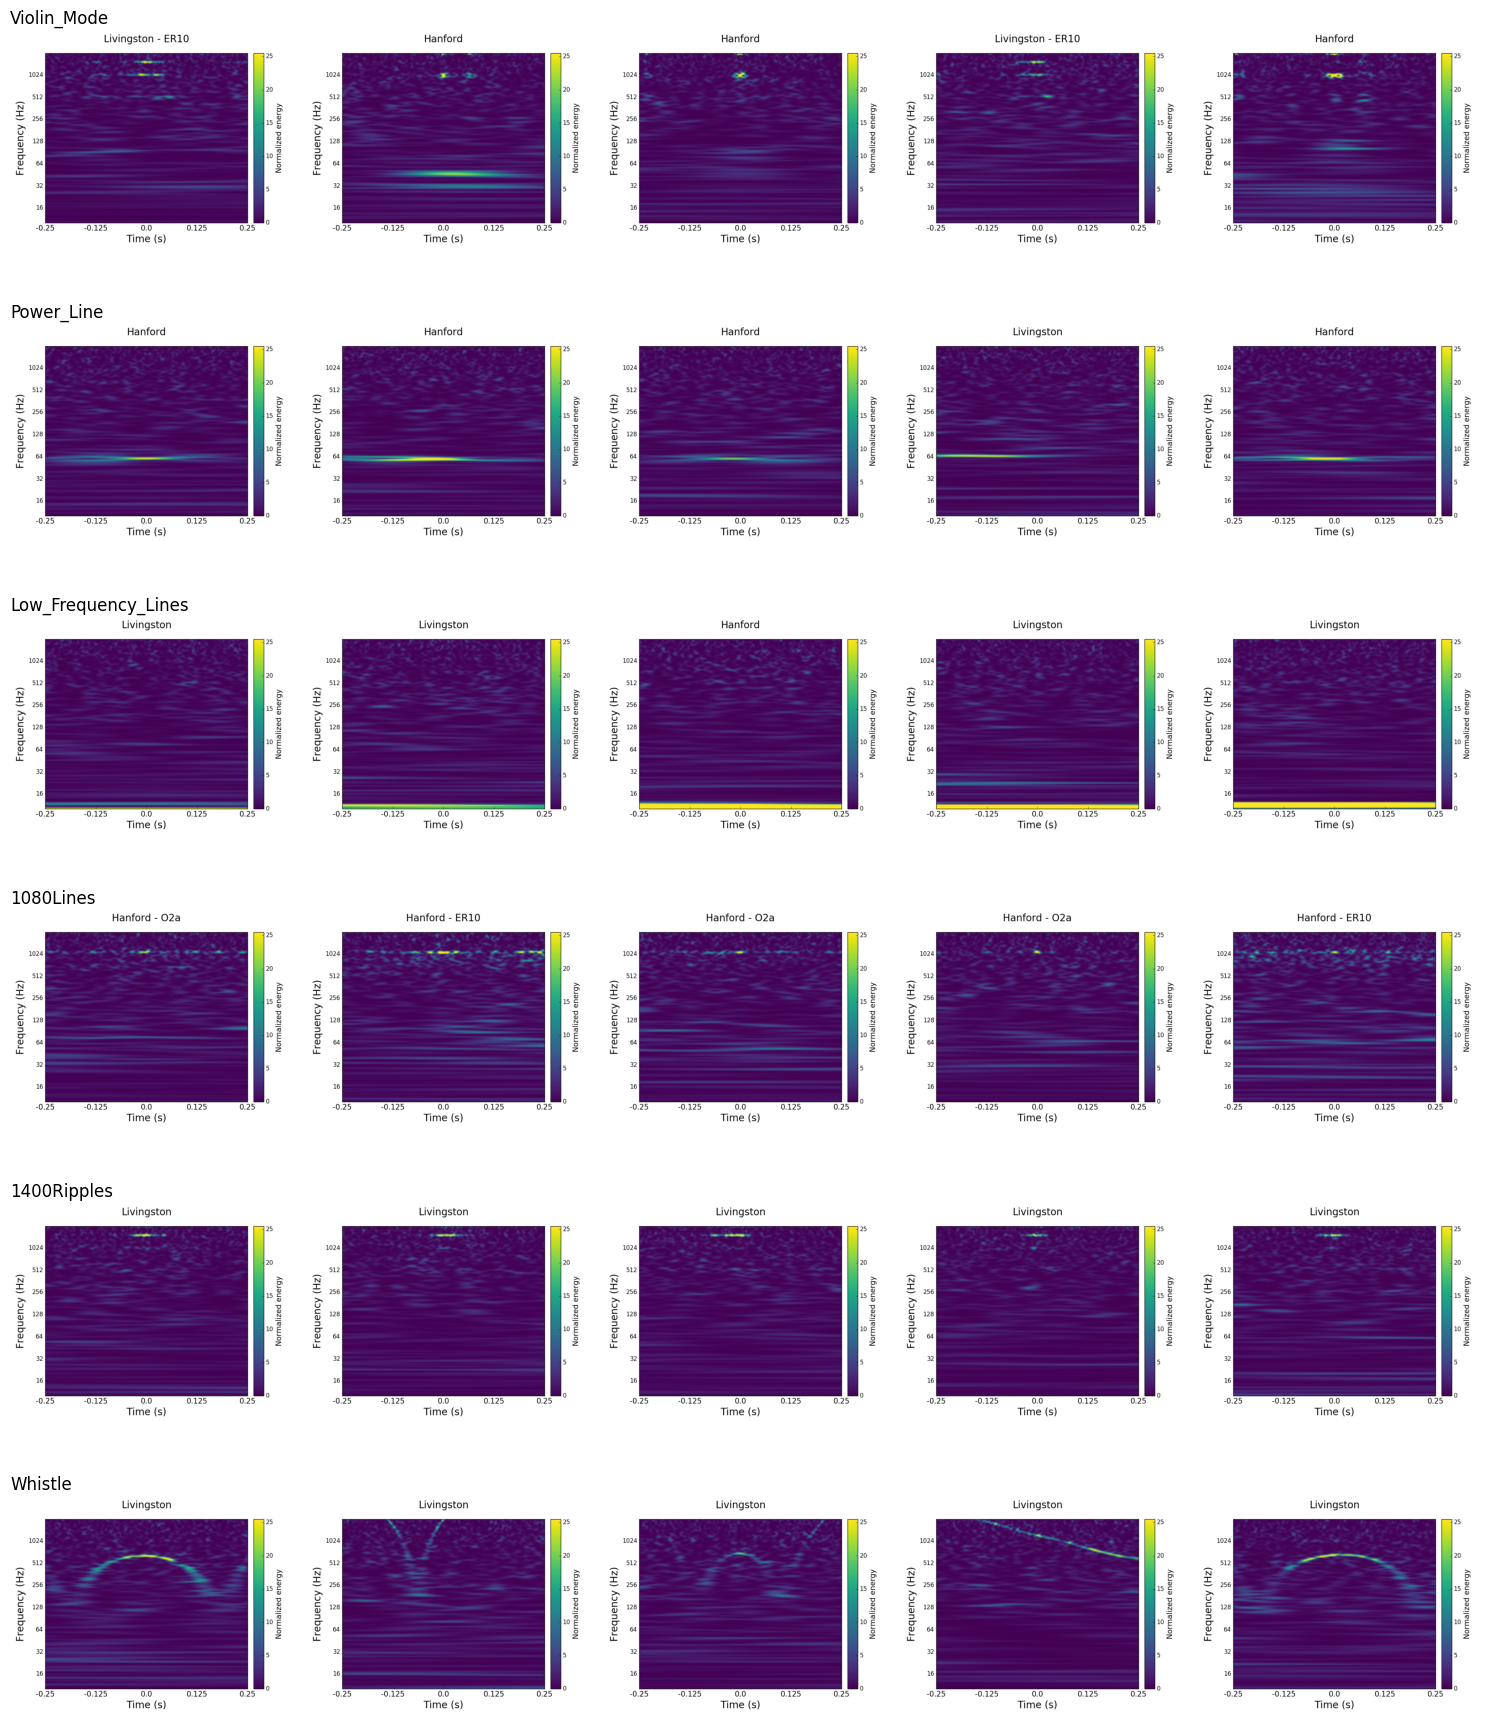

In [30]:
import random
from PIL import Image
import matplotlib.pyplot as plt

# --- settings (keep it controlled) ---
CLUSTER_ID = 33
TOP_K_LABELS = 6          # start with top 6 labels for readability
N_PER_LABEL = 5
SEED = 42                 # reproducible

random.seed(SEED)

cluster = meta[meta["cluster_id"] == CLUSTER_ID].copy()

# pick top labels in this cluster
top_labels = cluster["label_name"].value_counts().head(TOP_K_LABELS).index.tolist()
print("Top labels used:", top_labels)

# sample N_PER_LABEL paths per label
samples = []
for lab in top_labels:
    paths = cluster.loc[cluster["label_name"] == lab, "path"].tolist()
    # reproducible sample
    pick = random.sample(paths, k=min(N_PER_LABEL, len(paths)))
    for p in pick:
        samples.append((lab, p))

# --- plot grid ---
nrows = len(top_labels)
ncols = N_PER_LABEL
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 3*nrows))

# handle case where matplotlib returns 1D axes
if nrows == 1:
    axes = [axes]

for r, lab in enumerate(top_labels):
    row = [s for s in samples if s[0] == lab]
    for c in range(ncols):
        ax = axes[r][c] if nrows > 1 else axes[c]
        ax.axis("off")
        if c < len(row):
            p = row[c][1]
            try:
                img = Image.open(p)
                ax.imshow(img)
            except Exception as e:
                ax.text(0.5, 0.5, f"ERR\n{type(e).__name__}", ha="center", va="center")
        if c == 0:
            ax.set_title(lab, fontsize=12, loc="left")

plt.tight_layout()
from pathlib import Path
out_dir = Path("../findings/cluster_33_deep_dive")
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / "cluster33_contact_sheet_top6x5.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")

print("Saved:", out_path)
plt.show()



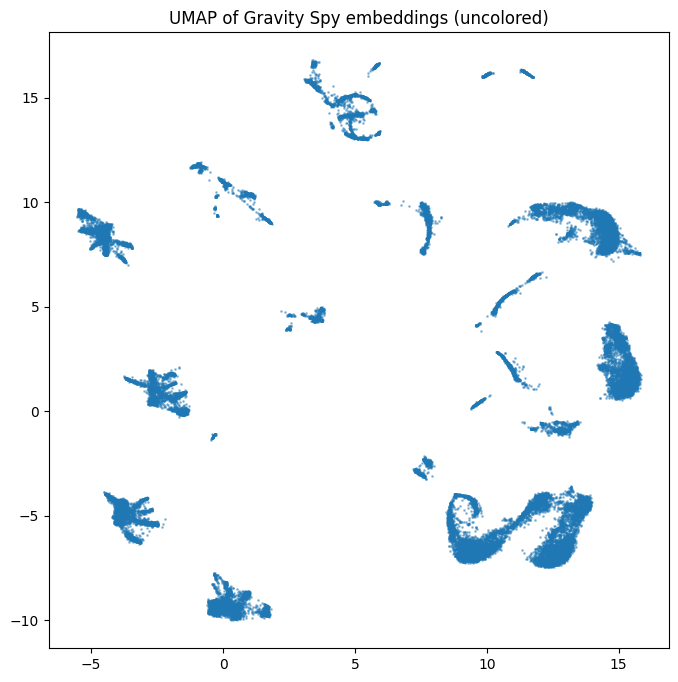

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.scatter(meta["umap_x"], meta["umap_y"], s=1, alpha=0.4)
plt.title("UMAP of Gravity Spy embeddings (uncolored)")
plt.show()


In [9]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    metric="euclidean",
    cluster_selection_method="eom",
)

cluster_labels = clusterer.fit_predict(meta[["umap_x", "umap_y"]].values)
meta["cluster_id"] = cluster_labels

meta["cluster_id"].value_counts().head()


KeyError: "None of [Index(['umap_x', 'umap_y'], dtype='object')] are in the [columns]"

In [7]:
meta.to_csv("../data/gravityspy_processed/embeddings_umap_hdbscan.csv", index=False)


In [7]:
cluster_stats = (
    meta[meta["cluster_id"] != -1]  # exclude noise
      .groupby("cluster_id")
      .agg(
          n=("label_name", "size"),
          top_label=("label_name", lambda x: x.value_counts().idxmax()),
          top_label_count=("label_name", lambda x: x.value_counts().max()),
      )
)

cluster_stats["purity"] = cluster_stats["top_label_count"] / cluster_stats["n"]
cluster_stats.sort_values("n", ascending=False).head(15)


KeyError: 'cluster_id'

In [8]:
print(meta.columns.tolist())


['path', 'label_idx', 'label_name', 'gravityspy_id', 'true_label', 'label_name_fixed', 'true_label_from_path']


In [23]:
# Focus only on clusters where the top label is Blip
blip_clusters = (
    cluster_stats
    .reset_index()
    .query("top_label == 'Blip'")
    .sort_values("n", ascending=False)
)

blip_clusters[["cluster_id", "n", "purity"]].head(10)


,cluster_id,n,purity
41,41,3915,0.476628
5,5,3697,0.505004
28,28,3498,0.530589
10,10,3479,0.536648


In [24]:
# Focus on cluster 41
cluster_41 = meta[meta["cluster_id"] == 41]

print("Total points in cluster 41:", len(cluster_41))
print("\nLabel composition:")
print(cluster_41["label_name"].value_counts().head(10))

print("\nLabel fractions:")
print(cluster_41["label_name"].value_counts(normalize=True).head(10).round(3))


Total points in cluster 41: 3915

Label composition:
label_name
Blip                   1866
Koi_Fish                813
Low_Frequency_Burst     468
Light_Modulation        374
Tomte                   114
Repeating_Blips          79
No_Glitch                70
Chirp                    64
None_of_the_Above        36
Scratchy                 14
Name: count, dtype: int64

Label fractions:
label_name
Blip                   0.477
Koi_Fish               0.208
Low_Frequency_Burst    0.120
Light_Modulation       0.096
Tomte                  0.029
Repeating_Blips        0.020
No_Glitch              0.018
Chirp                  0.016
None_of_the_Above      0.009
Scratchy               0.004
Name: proportion, dtype: float64


In [9]:
import plotly.express as px

fig = px.scatter(
    meta,
    x="umap_x",
    y="umap_y",
    color="cluster_id",
    hover_data=["label_name", "path"],
    height=800,
    width=800,
)
fig.show()


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Top labels used: ['Blip', 'Koi_Fish', 'Low_Frequency_Burst', 'Light_Modulation', 'Tomte', 'Repeating_Blips']


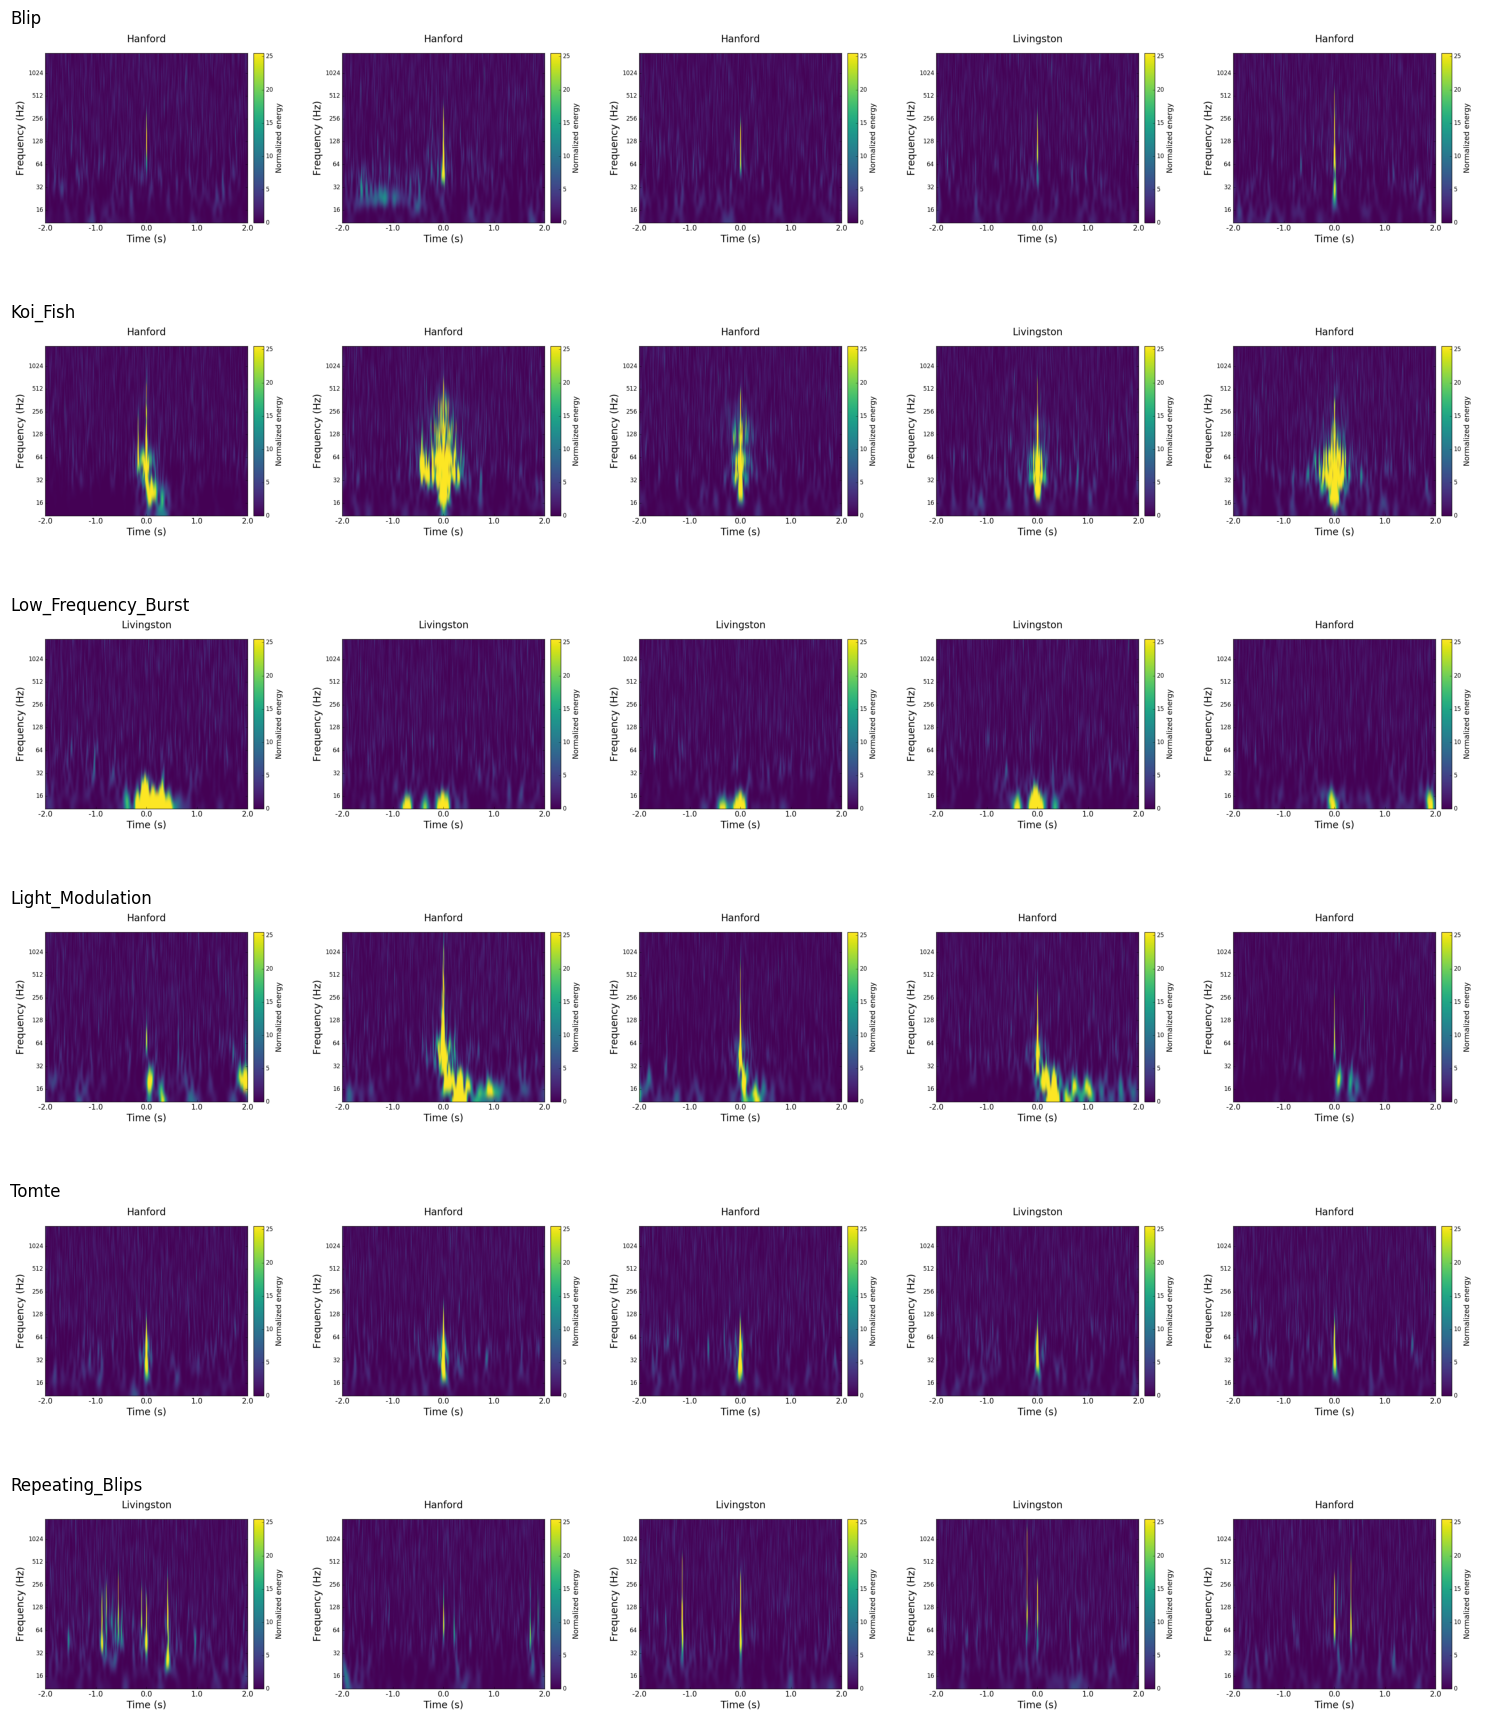

In [25]:
import random
from PIL import Image
import matplotlib.pyplot as plt

# --- settings ---
CLUSTER_ID = 41
TOP_K_LABELS = 6
N_PER_LABEL = 5
SEED = 42

random.seed(SEED)

cluster = meta[meta["cluster_id"] == CLUSTER_ID].copy()

top_labels = cluster["label_name"].value_counts().head(TOP_K_LABELS).index.tolist()
print("Top labels used:", top_labels)

samples = []
for lab in top_labels:
    paths = cluster.loc[cluster["label_name"] == lab, "path"].tolist()
    pick = random.sample(paths, k=min(N_PER_LABEL, len(paths)))
    for p in pick:
        samples.append((lab, p))

nrows = len(top_labels)
ncols = N_PER_LABEL
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3*ncols, 3*nrows))

if nrows == 1:
    axes = [axes]

for r, lab in enumerate(top_labels):
    row = [s for s in samples if s[0] == lab]
    for c in range(ncols):
        ax = axes[r][c] if nrows > 1 else axes[c]
        ax.axis("off")
        if c < len(row):
            try:
                img = Image.open(row[c][1])
                ax.imshow(img)
            except Exception as e:
                ax.text(0.5, 0.5, "ERR", ha="center", va="center")
        if c == 0:
            ax.set_title(lab, fontsize=12, loc="left")

plt.tight_layout()
plt.show()


In [26]:
import numpy as np
from PIL import Image

# Work only within cluster 41
cluster_41 = meta[meta["cluster_id"] == 41].copy()

def image_intensity(path):
    img = Image.open(path).convert("L")  # grayscale
    return np.asarray(img).sum()

# Compute intensity (may take ~1 minute)
cluster_41["intensity"] = cluster_41["path"].apply(image_intensity)

print(cluster_41["intensity"].describe())


count    3.915000e+03
mean     5.956302e+07
std      7.741557e+05
min      5.762463e+07
25%      5.908432e+07
50%      5.924814e+07
75%      5.978897e+07
max      6.489398e+07
Name: intensity, dtype: float64


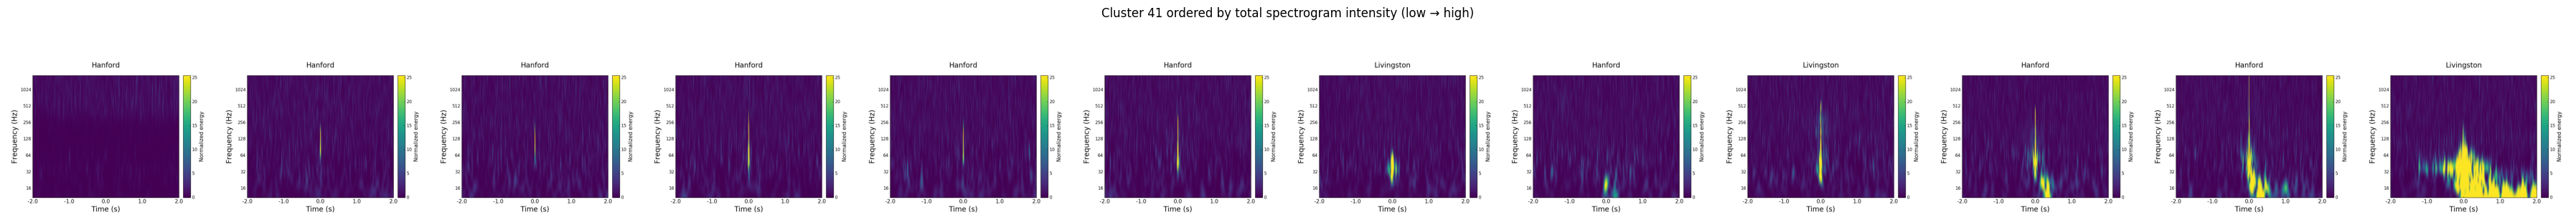

In [27]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Sort by intensity
cluster_41_sorted = cluster_41.sort_values("intensity")

# Pick evenly spaced samples across the range
N_SAMPLES = 12
indices = np.linspace(0, len(cluster_41_sorted) - 1, N_SAMPLES).astype(int)
samples = cluster_41_sorted.iloc[indices]

# Plot as a single ordered row
fig, axes = plt.subplots(1, N_SAMPLES, figsize=(3 * N_SAMPLES, 3))

for ax, (_, row) in zip(axes, samples.iterrows()):
    ax.axis("off")
    img = Image.open(row["path"])
    ax.imshow(img)

plt.suptitle("Cluster 41 ordered by total spectrogram intensity (low → high)", y=1.05)
plt.tight_layout()
plt.show()


In [28]:
from pathlib import Path
import matplotlib.pyplot as plt

out_dir = Path("../findings/cluster_41_deep_dive")
out_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / "cluster41_ordered_by_intensity_strip.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
print("Saved:", out_path)
plt.show()


Saved: ..\findings\cluster_41_deep_dive\cluster41_ordered_by_intensity_strip.png


<Figure size 640x480 with 0 Axes>

In [29]:
import numpy as np

def label_entropy(labels):
    counts = labels.value_counts(normalize=True)
    return -(counts * np.log2(counts)).sum()

entropy_33 = label_entropy(meta.loc[meta["cluster_id"] == 33, "label_name"])
entropy_41 = label_entropy(meta.loc[meta["cluster_id"] == 41, "label_name"])

print("Label entropy:")
print(f"Cluster 33: {entropy_33:.3f}")
print(f"Cluster 41: {entropy_41:.3f}")


Label entropy:
Cluster 33: 2.817
Cluster 41: 2.263


Saved: C:\Users\mygam\Documents\gravityspy-glitch-explorer\findings\cluster_41_deep_dive\cluster41_ordered_by_intensity_strip.png


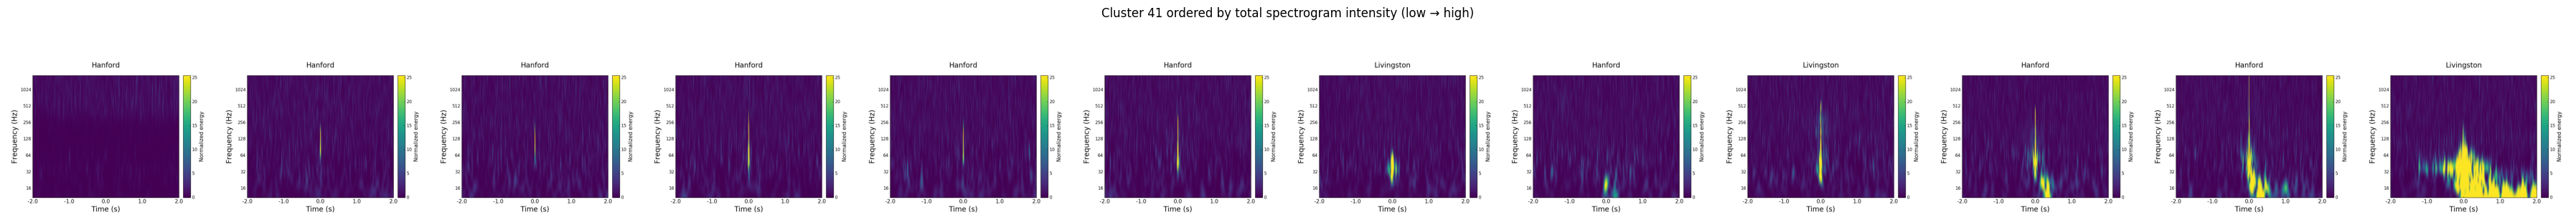

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# Sort by intensity
cluster_41_sorted = cluster_41.sort_values("intensity")

# Pick evenly spaced samples across the range
N_SAMPLES = 12
indices = np.linspace(0, len(cluster_41_sorted) - 1, N_SAMPLES).astype(int)
samples = cluster_41_sorted.iloc[indices]

# Plot ordered strip
fig, axes = plt.subplots(1, N_SAMPLES, figsize=(3 * N_SAMPLES, 3))
for ax, (_, row) in zip(axes, samples.iterrows()):
    ax.axis("off")
    ax.imshow(Image.open(row["path"]))

plt.suptitle("Cluster 41 ordered by total spectrogram intensity (low → high)", y=1.05)
plt.tight_layout()

# Save BEFORE show
out_dir = Path("../findings/cluster_41_deep_dive")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "cluster41_ordered_by_intensity_strip.png"

plt.savefig(out_path, dpi=200, bbox_inches="tight")
print("Saved:", out_path.resolve())

plt.show()


Saved: C:\Users\mygam\Documents\gravityspy-glitch-explorer\figures\paper\fig1_umap_global_by_cluster.png


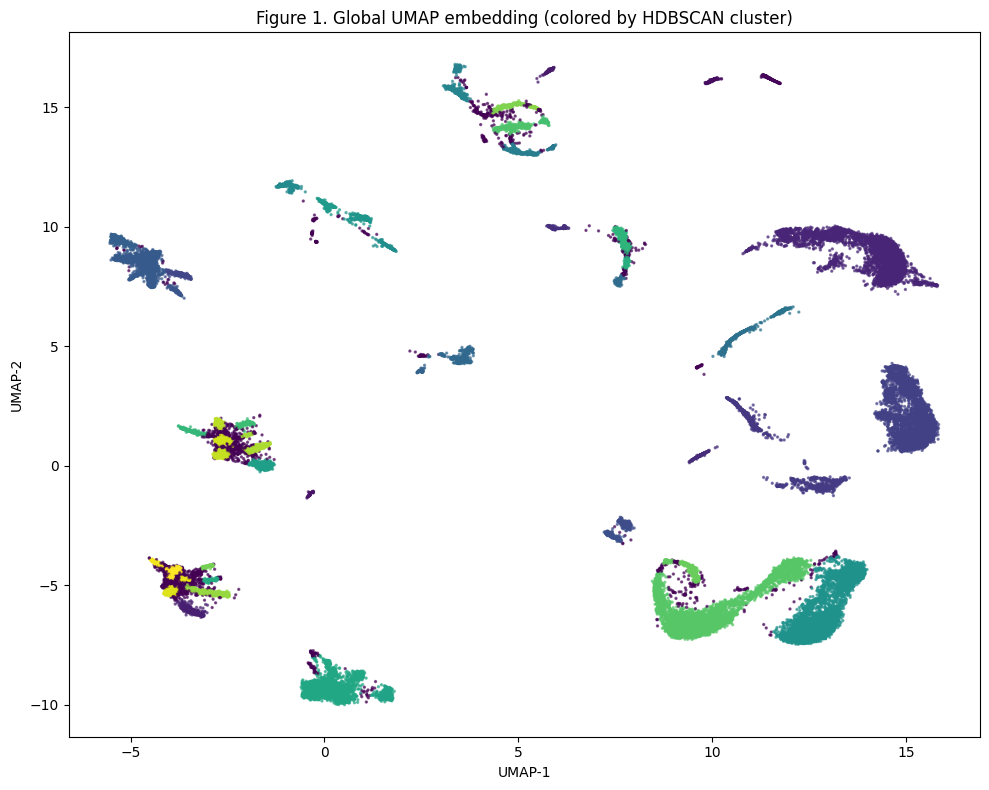

In [32]:
import matplotlib.pyplot as plt
from pathlib import Path

# --- output location ---
out_dir = Path("../figures/paper")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "fig1_umap_global_by_cluster.png"

# --- plot ---
plt.figure(figsize=(10, 8))
plt.scatter(
    meta["umap_x"], meta["umap_y"],
    c=meta["cluster_id"],
    s=2,
    alpha=0.6
)
plt.title("Figure 1. Global UMAP embedding (colored by HDBSCAN cluster)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.tight_layout()

# save BEFORE show
plt.savefig(out_path, dpi=250, bbox_inches="tight")
print("Saved:", out_path.resolve())
plt.show()


Saved: C:\Users\mygam\Documents\gravityspy-glitch-explorer\figures\paper\fig2_ambiguity_ranked_clusters_top15.png


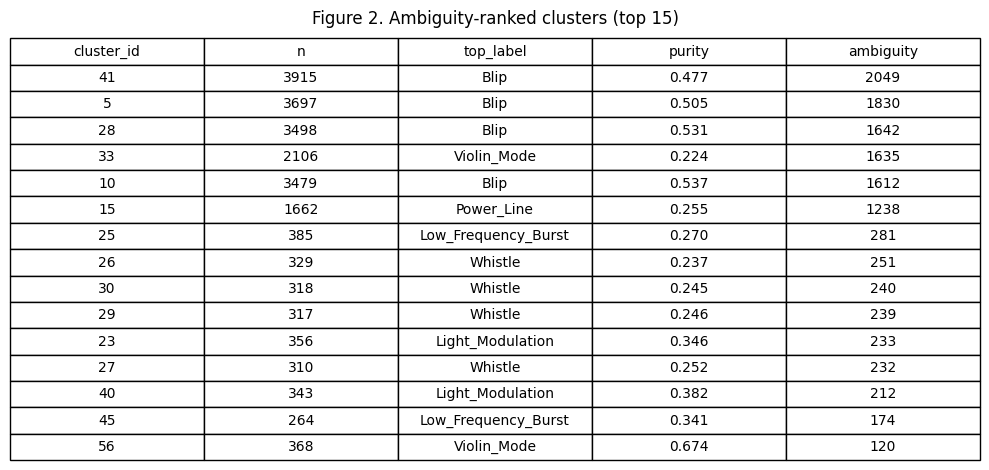

In [33]:
import matplotlib.pyplot as plt
from pathlib import Path

# Build ambiguity table (top 15)
fig2 = cluster_stats.copy()
fig2["ambiguity"] = (1 - fig2["purity"]) * fig2["n"]
fig2 = fig2.sort_values("ambiguity", ascending=False).head(15)

# Format for display
display_tbl = fig2.reset_index()[["cluster_id", "n", "top_label", "purity", "ambiguity"]].copy()
display_tbl["purity"] = display_tbl["purity"].map(lambda x: f"{x:.3f}")
display_tbl["ambiguity"] = display_tbl["ambiguity"].map(lambda x: f"{x:.0f}")

# Save location
out_dir = Path("../figures/paper")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "fig2_ambiguity_ranked_clusters_top15.png"

# Render table as figure
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.axis("off")
ax.set_title("Figure 2. Ambiguity-ranked clusters (top 15)", pad=12)

table = ax.table(
    cellText=display_tbl.values,
    colLabels=display_tbl.columns,
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

plt.tight_layout()
plt.savefig(out_path, dpi=250, bbox_inches="tight")
print("Saved:", out_path.resolve())
plt.show()


Saved: C:\Users\mygam\Documents\gravityspy-glitch-explorer\figures\paper\fig5_label_entropy_cluster33_vs_cluster41.png


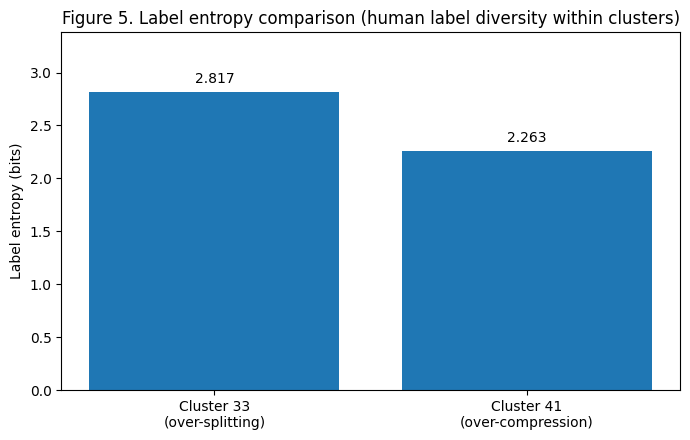

In [34]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

# If you already computed these earlier, reuse them; otherwise recompute safely:
def label_entropy(labels):
    counts = labels.value_counts(normalize=True)
    return -(counts * np.log2(counts)).sum()

entropy_33 = label_entropy(meta.loc[meta["cluster_id"] == 33, "label_name"])
entropy_41 = label_entropy(meta.loc[meta["cluster_id"] == 41, "label_name"])

vals = [entropy_33, entropy_41]
labels = ["Cluster 33\n(over-splitting)", "Cluster 41\n(over-compression)"]

# Save location
out_dir = Path("../figures/paper")
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / "fig5_label_entropy_cluster33_vs_cluster41.png"

# Plot
plt.figure(figsize=(7, 4.5))
plt.bar(labels, vals)
plt.ylabel("Label entropy (bits)")
plt.title("Figure 5. Label entropy comparison (human label diversity within clusters)")
plt.ylim(0, max(vals) * 1.2)

# annotate values
for i, v in enumerate(vals):
    plt.text(i, v + (max(vals) * 0.03), f"{v:.3f}", ha="center")

plt.tight_layout()
plt.savefig(out_path, dpi=250, bbox_inches="tight")
print("Saved:", out_path.resolve())
plt.show()
